In [21]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [22]:
dataset_path = '/content/drive/MyDrive/DEEPLRL_Data'

In [23]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

In [24]:
datagen = ImageDataGenerator(
    rescale = 1./255,
    validation_split = 0.2
)

In [25]:
train_data = datagen.flow_from_directory(
    dataset_path,
    target_size = (128,128),
    batch_size = 32,
    class_mode='categorical',
    subset = 'training'
)

Found 340 images belonging to 5 classes.


In [26]:
validation_data = datagen.flow_from_directory(
    dataset_path,
    target_size = (128,128),
    batch_size = 32,
    class_mode='categorical',
    subset = 'validation'
)

Found 83 images belonging to 5 classes.


In [27]:
model = models.Sequential()

In [28]:
model.add(layers.Conv2D(32,(3,3),
                        activation='relu', input_shape=(128,128,3)))
model.add(layers.MaxPooling2D((2,2)))

In [29]:
model.add(layers.Conv2D(64,(3,3),
                        activation='relu'))
model.add(layers.MaxPooling2D((2,2)))

In [30]:
model.add(layers.Flatten())

In [31]:
model.add(layers.Dense(train_data.num_classes, activation='softmax'))

In [32]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [33]:
history = model.fit(
    train_data,
    epochs = 10,
    validation_data = validation_data
)

Epoch 1/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 75s 7s/step - accuracy: 0.4941 - loss: 1.5495 - val_accuracy: 0.3253 - val_loss: 1.5098
Epoch 2/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 40s 4s/step - accuracy: 0.8559 - loss: 0.5195 - val_accuracy: 0.3735 - val_loss: 2.1629
Epoch 3/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 38s 3s/step - accuracy: 0.9382 - loss: 0.2389 - val_accuracy: 0.4217 - val_loss: 2.8070
Epoch 4/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 38s 4s/step - accuracy: 0.9559 - loss: 0.1214 - val_accuracy: 0.4699 - val_loss: 2.9668
Epoch 5/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 39s 3s/step - accuracy: 0.9824 - loss: 0.0532 - val_accuracy: 0.4096 - val_loss: 3.5405
Epoch 6/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 40s 4s/step - accuracy: 0.9912 - loss: 0.0310 - val_accuracy: 0.4819 - val_loss: 3.0970
Epoch 7/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 38s 4s/step - accuracy: 0.9971 - loss: 0.0179 - val_accuracy: 0.4578 - val_loss: 3.7111
Epoch 8/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 40s 4s/step - accuracy: 1.0000 - loss: 0.0104 - val_accuracy: 0.4819 - val_loss:

In [34]:
loss, accuracy = model.evaluate(validation_data)
print('Validation Accuracy:', accuracy)

3/3 ━━━━━━━━━━━━━━━━━━━━ 6s 2s/step - accuracy: 0.4819 - loss: 3.8883
Validation Accuracy: 0.4819277226924896


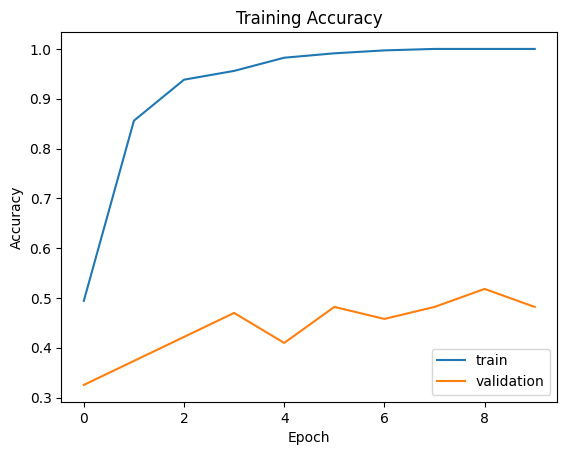

In [35]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['train', 'validation'])

plt.show()

In [36]:
model.save("cnn_classifier.h5")

In [37]:
from google.colab import files
files.download("cnn_classifier.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Streamlit next

In [38]:
from google.colab import files
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt


In [45]:


# Upload image from local computer
uploaded = files.upload()

# Get the uploaded filename
filename = list(uploaded.keys())[0]

# Load and resize image
img = image.load_img(filename, target_size=(128,128))

# Convert image to array
img_array = image.img_to_array(img)

# Normalize pixel values
img_array = img_array / 255.0

# Expand dimensions to match model input
img_array = np.expand_dims(img_array, axis=0)

# Make prediction
prediction = model.predict(img_array)

# Get predicted class index
predicted_class = np.argmax(prediction)

# Get class label names
class_labels = list(train_data.class_indices.keys())



Saving WIN_20260430_17_08_17_Pro.jpg to WIN_20260430_17_08_17_Pro.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


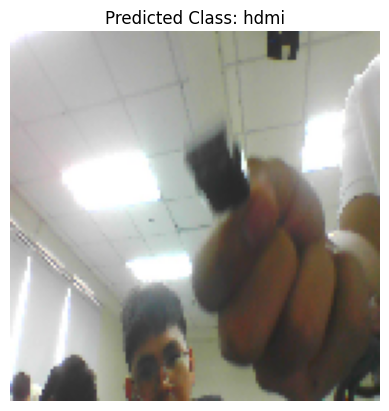

In [46]:
# Display image
plt.imshow(img)
plt.axis('off')
plt.title("Predicted Class: " + class_labels[predicted_class])
plt.show()